# BAMv3 실험: 노이즈→노이즈 학습

**Ultra-low SNR 환경을 위한 Robust Feature Learning**
- Self-supervised 학습 방식
- 다양한 SNR에서 일관된 패턴 학습
- 병목 효과로 랜덤 노이즈 제거
- 노이즈 범위 줄임(5~-5db)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa, MultiBAMv3_Huber, BAMv3_Huber
import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)


/home/gwon9906/LoRa-bam-reconstruction/utils/my_lora_utils.py


In [2]:
from scipy.signal import stft, istft

STFT_PARAMS = {
    'nperseg': 128,
    'noverlap': 64,
    'nfft': 512,      
    'window': 'hann'
}

def generate_complex_spectrogram(iq_signal, fs, bw=250_000):
    nperseg  = STFT_PARAMS['nperseg']
    noverlap = STFT_PARAMS['noverlap']
    nfft     = STFT_PARAMS['nfft']  # <--- 변수 가져오기
    window   = STFT_PARAMS['window']

    # 2. stft 호출 시 nfft 전달
    f, t, Zxx = stft(
        iq_signal,
        fs=fs,
        window=window,
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft,              
        boundary=None,
        padded=False,
        return_onesided=False
    )

    # 2) 주파수축 shift 후 BW 크롭
    f_shifted    = np.fft.fftshift(f)
    Zxx_shifted  = np.fft.fftshift(Zxx, axes=0)
    original_shape = Zxx_shifted.shape

    mask = (f_shifted >= -bw/2) & (f_shifted < bw/2)
    freq_indices = np.where(mask)[0]
    Zxx_cropped  = Zxx_shifted[mask, :]   # (F_bw, T)

    # 3) Real / Imag 분리 + min-max 정규화
    real_part = Zxx_cropped.real
    imag_part = Zxx_cropped.imag

    r_min, r_max = real_part.min(), real_part.max()
    i_min, i_max = imag_part.min(), imag_part.max()

    real_norm = (real_part - r_min) / (r_max - r_min + 1e-12)
    imag_norm = (imag_part - i_min) / (i_max - i_min + 1e-12)

    # 4) 플랫 벡터로 합치기
    real_flat = real_norm.flatten()
    imag_flat = imag_norm.flatten()
    combined_flat = np.concatenate([real_flat, imag_flat])

    # 5) 복원을 위한 메타 정보 저장
    norm_params = {
        'r_min': r_min, 'r_max': r_max,
        'i_min': i_min, 'i_max': i_max,
        'shape': Zxx_cropped.shape,        # (F_bw, T)
        'original_shape': original_shape,  # full Zxx shape
        'freq_indices': freq_indices,
        'stft_params': STFT_PARAMS.copy(),
        'orig_len': len(iq_signal),        # 원래 IQ 길이 (예: 2048)
    }

    return combined_flat, norm_params

def reconstruct_iq_from_spectrogram(restored_flat, norm_params, fs):
    """
    BAM 복원 스펙트로그램(flat) → complex STFT → ISTFT → IQ 신호
    (재학습 버전용)
    """
    cropped_shape = norm_params['shape']   # (F_bw, T)
    mid = len(restored_flat) // 2

    # 1) Real/Imag 복원 + reshape
    real_restored_norm = restored_flat[:mid].reshape(cropped_shape)
    imag_restored_norm = restored_flat[mid:].reshape(cropped_shape)

    # 2) 역정규화
    real_restored = (
        real_restored_norm * (norm_params['r_max'] - norm_params['r_min'])
        + norm_params['r_min']
    )
    imag_restored = (
        imag_restored_norm * (norm_params['i_max'] - norm_params['i_min'])
        + norm_params['i_min']
    )

    Zxx_cropped = real_restored + 1j * imag_restored   # (F_bw, T)

    # 3) full STFT 행렬로 복원
    Zxx_full = np.zeros(norm_params['original_shape'], dtype=complex)
    Zxx_full[norm_params['freq_indices'], :] = Zxx_cropped

    # 4) ifftshift로 원래 STFT 형태로 되돌림
    Zxx_unshifted = np.fft.ifftshift(Zxx_full, axes=0)

    # 5) ISTFT (STFT와 완전히 동일한 파라미터 사용)
    stft_params = norm_params['stft_params']
    _, iq_restored = istft(
        Zxx_unshifted,
        fs=fs,
        window=stft_params['window'],
        nperseg=stft_params['nperseg'],
        noverlap=stft_params['noverlap'],
        nfft=stft_params['nfft'],
        input_onesided=False,
        boundary=None,
    )

    # 6) 길이 보정 (pad/crop만, resample 사용 ❌)
    target_len = norm_params.get('orig_len', len(iq_restored))

    if len(iq_restored) > target_len:
        iq_restored = iq_restored[:target_len]
    elif len(iq_restored) < target_len:
        iq_restored = np.pad(iq_restored, (0, target_len - len(iq_restored)), mode='edge')

    return iq_restored

In [3]:
# LoRa 파라미터 설정
sf = 9
bw = 250_000  # 250 kHz
OSF = 4
fs = int(bw * OSF)  # 1 MHz

print(f"SF = {sf}, BW = {bw/1e3:.1f} kHz, fs = {fs/1e6:.3f} MHz")

# LoRa 인스턴스 생성 (on-the-fly 노이즈 추가용)
lora = LoRa(sf=sf, bw=bw, OSF=OSF)
fs = lora.fs   # = bw * OSF


SF = 9, BW = 250.0 kHz, fs = 1.000 MHz


In [4]:
########################################
##  1. 클린 IQ 데이터 로드            ##
########################################

base_dir = "dataset_v3_sf9_bw250k"
iq_dir = os.path.join(base_dir, "clean_iq")

print("Loading clean IQ data...")
iq_files = sorted(glob.glob(os.path.join(iq_dir, "*.npy")))
print(f"Found {len(iq_files)} clean IQ files")

# 클린 IQ 로드
iq_data_list = []
for f in iq_files:
    x_clean = np.load(f)  # complex IQ
    iq_data_list.append(x_clean)

X_clean_iq = np.array(iq_data_list)
print(f"Clean IQ shape: {X_clean_iq.shape}, dtype: {X_clean_iq.dtype}")


Loading clean IQ data...
Found 512 clean IQ files
Clean IQ shape: (512, 2048), dtype: complex64


In [ ]:
########################################
##  2. 데이터 증강 함수 정의          ##
########################################

# SNR 범위 설정 (SNR에 집중)
SNR_MIN = -20
SNR_MAX = 0
AUGMENT_FACTOR = 30  # 각 클린 IQ를 30배로 증강

def augment_dataset(X_clean_iq, augment_factor=30):
    """
    클린 IQ를 N배로 증강 (매번 다른 랜덤 노이즈 추가)
    Complex 스펙트로그램 사용 (Phase 정보 보존)
    
    Returns:
        X_noisy_flat: (512*augment_factor, input_dim) 형태
        norm_params_list: 각 샘플의 역정규화 파라미터
    """
    print(f"\nGenerating {len(X_clean_iq)} × {augment_factor} = {len(X_clean_iq) * augment_factor} augmented samples...")
    
    X_noisy_flat_list = []
    norm_params_list = []
    
    for clean_iq in X_clean_iq:
        for _ in range(augment_factor):
            # 랜덤 SNR 선택
            snr = np.random.randint(SNR_MIN, SNR_MAX + 1)
            
            # 노이즈 추가
            noisy_iq = lora.awgn_iq(clean_iq, snr)
            
            # Complex 스펙트로그램 생성 (Phase 보존)
            spec_flat, norm_params = generate_complex_spectrogram(noisy_iq, fs, bw)
            X_noisy_flat_list.append(spec_flat)
            norm_params_list.append(norm_params)
    
    X_noisy_flat = np.array(X_noisy_flat_list)
    
    print(f"Augmented dataset shape: {X_noisy_flat.shape}")
    print(f"  - Real/Imag combined (Phase preserved)")
    
    return X_noisy_flat, norm_params_list

print(f"✅ Complex augmentation function defined: {AUGMENT_FACTOR}x per clean IQ")


✅ Complex augmentation function defined: 30x per clean IQ


In [6]:
########################################
##  3. 모델 아키텍처 설정             ##
########################################

# Complex 스펙트로그램 shape 확인을 위한 테스트 (1개만)
test_spec_flat, test_params = generate_complex_spectrogram(X_clean_iq[0], fs, bw)
input_dim = test_spec_flat.shape[0]  # Real + Imag 통합 (2배)

# 점진적 압축: 7936 → 4096 → 3072 → 2048
layers = [input_dim, 4096, 2048, 1024]

print(f"Complex spectrogram shape: {test_params['shape']}")
print(f"Input dim (Real+Imag): {input_dim}")
print(f"Model architecture: {' → '.join(map(str, layers))}")
print(f"Compression ratio: {input_dim / layers[-1]:.1f}x")
print(f"Layers: {len(layers)-1} BAM layers (더 부드러운 압축)")


Complex spectrogram shape: (128, 31)
Input dim (Real+Imag): 7936
Model architecture: 7936 → 4096 → 2048 → 1024
Compression ratio: 7.8x
Layers: 3 BAM layers (더 부드러운 압축)



=== Training MultiBAMv3_Huber Model (Complex Spectrogram) ===
Architecture: 7936 → 4096 → 2048 → 1024
Strategy: On-the-fly 30x Augmentation per Epoch (Phase Preserved)

=== Starting Training with On-the-fly Complex Augmentation ===
Base samples: 512
Augmentation factor: 30x

Epoch 1/30

Generating 512 × 30 = 15360 augmented samples...
Augmented dataset shape: (15360, 7936)
  - Real/Imag combined (Phase preserved)
   > Layer 1 Training... (Delta: 0.01)
   > Layer 2 Training... (Delta: 0.01)
   > Layer 3 Training... (Delta: 0.01)
   -> Layer 1 Final Loss: 0.001707
   -> Layer 2 Final Loss: 0.003870
   -> Layer 3 Final Loss: 0.002523

Epoch 2/30

Generating 512 × 30 = 15360 augmented samples...
Augmented dataset shape: (15360, 7936)
  - Real/Imag combined (Phase preserved)
   > Layer 1 Training... (Delta: 0.01)
   > Layer 2 Training... (Delta: 0.01)
   > Layer 3 Training... (Delta: 0.01)
   -> Layer 1 Final Loss: 0.000533
   -> Layer 2 Final Loss: 0.002741
   -> Layer 3 Final Loss: 0.004

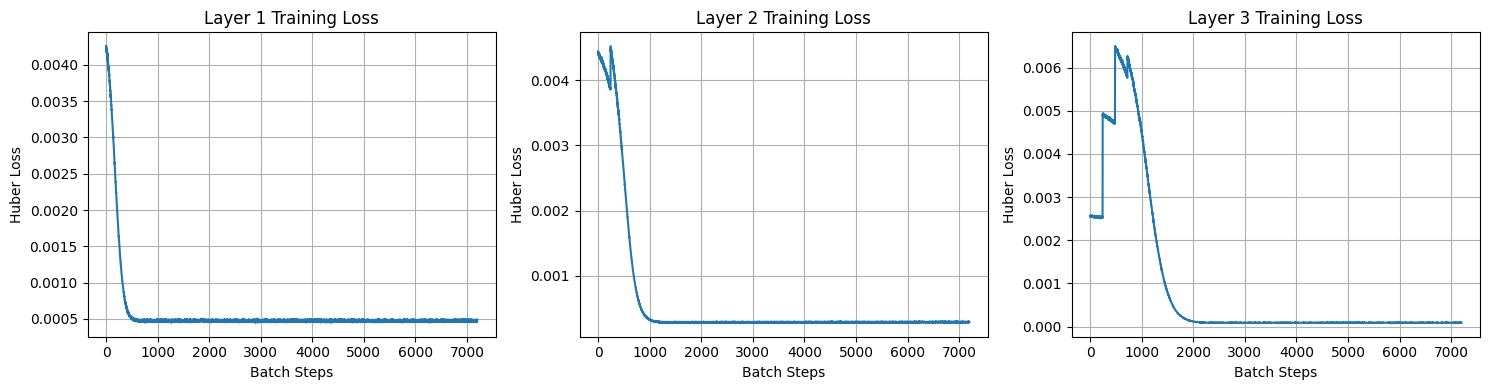

In [7]:
########################################
##  4. BAMv3 Complex 30배 증강 학습  ##
########################################

print(f"\n=== Training MultiBAMv3_Huber Model (Complex Spectrogram) ===")
print(f"Architecture: {' → '.join(map(str, layers))}")
print(f"Strategy: On-the-fly 30x Augmentation per Epoch (Phase Preserved)")

# [수정됨] MultiBAMv3_Huber 클래스 사용
model = MultiBAMv3_Huber(
    layers_dims=layers,      # [7936, 4096, 2048, 1024]
    eta=1e-4,                # 학습률
    huber_delta=1e-2,        # Huber Delta (0.01)
    device='cuda'
)

# 학습 플래그
TRAIN = True 

if TRAIN:
    print("\n=== Starting Training with On-the-fly Complex Augmentation ===")
    print(f"Base samples: {len(X_clean_iq)}")
    print(f"Augmentation factor: {AUGMENT_FACTOR}x")
    
    num_epochs = 30
    batch_size = 64
    
    all_layer_losses = [[] for _ in range(len(layers)-1)]
    
    for epoch in range(num_epochs):
        print(f"\n{'='*40}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*40}")
        
        # 1. 데이터 증강 (매 Epoch 새로운 노이즈)
        X_augmented, _ = augment_dataset(X_clean_iq, AUGMENT_FACTOR)
        
        # 2. 학습 (train 메서드 호출)
        # MultiBAMv3_Huber.train 내부에서 각 층을 순차적으로 학습함
        layer_losses = model.train(X_augmented, num_epochs=1, batch_size=batch_size)
        
        # 3. Loss 기록
        for i, losses in enumerate(layer_losses):
            all_layer_losses[i].extend(losses)
            # 각 층별 마지막 Loss 출력
            print(f"   -> Layer {i+1} Final Loss: {losses[-1]:.6f}")
    
    print("\n=== Training Complete ===")
    
    # Loss 플롯
    fig, axes = plt.subplots(1, len(all_layer_losses), figsize=(15, 4))
    if len(all_layer_losses) == 1: axes = [axes]
    
    for i, losses in enumerate(all_layer_losses):
        axes[i].plot(losses)
        axes[i].set_xlabel('Batch Steps')
        axes[i].set_ylabel('Huber Loss')
        axes[i].set_title(f'Layer {i+1} Training Loss')
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nTraining skipped (TRAIN=False)")

In [8]:
########################################
##  5. 모델 저장                     ##
########################################

import torch

if TRAIN:
    # 모델 저장 폴더
    weight_folder = "weights_bamv3_huber_complex"
    os.makedirs(weight_folder, exist_ok=True)
    
    # 각 layer의 weight 저장
    for i, bam in enumerate(model.bams):
        weight_path = os.path.join(weight_folder, f"weights_layer_{i}.npy")
        np.save(weight_path, bam.W.cpu().numpy())
        print(f"✅ Layer {i} weights saved to: {weight_path}")
    
    # 아키텍처 정보 저장
    config = {
        'layers': layers,
        'eta': 5e-4,
        'sf': sf,
        'bw': bw,
        'fs': fs,
        'mode': 'complex'  # Complex 방식 표시
    }
    config_path = os.path.join(weight_folder, "model_config.npy")
    np.save(config_path, config)
    print(f"✅ Config saved to: {config_path}")

print("\n=== How to Load Model ===")
print("""
# 모델 로드 예시:
config = np.load('weights_bamv3_complex/model_config.npy', allow_pickle=True).item()
model = MultiBAMv3(layers_dims=config['layers'], eta=config['eta'])
for i, bam in enumerate(model.bams):
    bam.W = torch.tensor(np.load(f'weights_bamv3_complex/weights_layer_{i}.npy'))
""")


✅ Layer 0 weights saved to: weights_bamv3_huber_complex/weights_layer_0.npy
✅ Layer 1 weights saved to: weights_bamv3_huber_complex/weights_layer_1.npy
✅ Layer 2 weights saved to: weights_bamv3_huber_complex/weights_layer_2.npy
✅ Config saved to: weights_bamv3_huber_complex/model_config.npy

=== How to Load Model ===

# 모델 로드 예시:
config = np.load('weights_bamv3_complex/model_config.npy', allow_pickle=True).item()
model = MultiBAMv3(layers_dims=config['layers'], eta=config['eta'])
for i, bam in enumerate(model.bams):
    bam.W = torch.tensor(np.load(f'weights_bamv3_complex/weights_layer_{i}.npy'))



In [9]:
########################################
##  5-1. 학습된 모델 로드 (TRAIN=False일 때)  ##
########################################

import torch

# TRAIN=False인 경우에만 저장된 모델 로드
if not TRAIN:
    weight_folder = "weights_bamv3_huber_complex"
    
    # Config 파일이 존재하는지 확인
    config_path = os.path.join(weight_folder, "model_config.npy")
    
    if os.path.exists(config_path):
        print(f"\n=== Loading Pre-trained Model ===")
        
        # Config 로드
        config = np.load(config_path, allow_pickle=True).item()
        print(f"Loaded config: {config}")
        
        # 아키텍처가 동일한지 확인
        if config['layers'] == layers:
            # 각 layer의 weight 로드
            for i, bam in enumerate(model.bams):
                weight_path = os.path.join(weight_folder, f"weights_layer_{i}.npy")
                if os.path.exists(weight_path):
                    loaded_weight = np.load(weight_path)
                    # 🔧 디바이스 지정 추가! (CPU/CUDA 자동 감지)
                    bam.W = torch.tensor(loaded_weight, dtype=torch.float32).to(bam.device)
                    print(f"✅ Layer {i} weights loaded from: {weight_path} (device: {bam.device})")
                else:
                    print(f"❌ Warning: {weight_path} not found!")
            
            print(f"✅ Model successfully loaded from {weight_folder}")
        else:
            print(f"❌ Warning: Architecture mismatch!")
            print(f"   Current: {layers}")
            print(f"   Saved:   {config['layers']}")
    else:
        print(f"❌ Warning: No pre-trained model found in {weight_folder}")
        print(f"   Please set TRAIN=True to train a new model first.")
else:
    print("\n=== Using Newly Trained Model ===")
    print("Model weights from training will be used.")



=== Using Newly Trained Model ===
Model weights from training will be used.



=== Testing Complex Reconstruction ===
Test symbol: 42, SNR: -10 dB

=== Normalization Parameters ===
Real: min=-1.434692, max=1.500760, range=2.935452
Imag: min=-1.448734, max=1.407222, range=2.855956
Restored norm: real_min=0.4878, real_max=0.5032
Restored norm: imag_min=0.4921, imag_max=0.5080
After denorm:  real_min=-0.002690, real_max=0.042304
After denorm:  imag_min=-0.043320, imag_max=0.002108
✅ IQ signal reconstructed: (2048,)
   ✅ Length already matches: 2048 samples
   🔧 Normalized to Unit Power (std=1.0)
   Energy after scaling:  |mean|=0.052792, |max|=44.529368

=== Debug: Values Check ===
Noisy flat:    min=0.0000, max=1.0000, mean=0.4977
Restored flat: min=0.4878, max=0.5080, mean=0.4976
Difference:    MSE=0.009541


/tmp/ipykernel_137125/2745113903.py:99: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


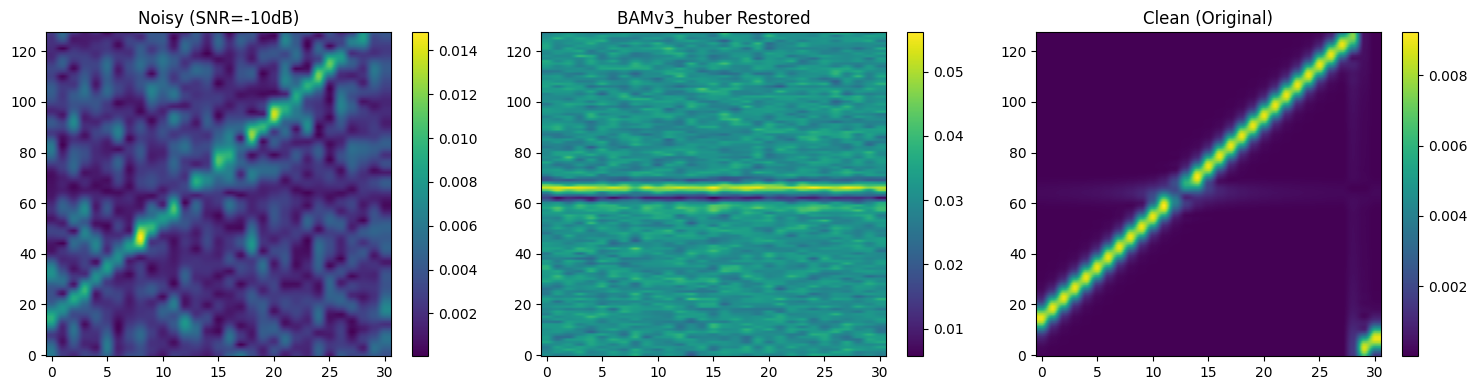


=== Spectrogram Magnitude Check ===
Zxx_noisy (magnitude):    min=0.0000, max=0.0148
Zxx_restored (magnitude): min=0.0057, max=0.0561
Zxx_clean (magnitude):    min=0.0000, max=0.0092


In [10]:
########################################
##  6. 테스트: Complex 복원 및 IQ 재구성  ##
########################################

# 테스트 샘플 선택
test_symbol = 42  # 테스트할 심볼 (0~511)
test_snr = -10    # 테스트 SNR

print(f"\n=== Testing Complex Reconstruction ===")
print(f"Test symbol: {test_symbol}, SNR: {test_snr} dB")

# 1. 클린 IQ 생성
clean_iq = X_clean_iq[test_symbol]

# 2. 노이즈 추가
noisy_iq = lora.awgn_iq(clean_iq, test_snr)

# 3. Complex 스펙트로그램 생성
noisy_flat, norm_params = generate_complex_spectrogram(noisy_iq, fs, bw)

# 4. BAM 압축/복원
compressed = model.compress(noisy_flat.reshape(1, -1))
restored_flat = model.decompress(compressed).flatten()

# 5. Real/Imag 분리 및 역정규화 (학습 시와 동일한 스케일 사용)
mid = len(restored_flat) // 2
real_restored_norm = restored_flat[:mid].reshape(norm_params['shape'])
imag_restored_norm = restored_flat[mid:].reshape(norm_params['shape'])

# 🔍 정규화 파라미터 확인
print(f"\n=== Normalization Parameters ===")
print(f"Real: min={norm_params['r_min']:.6f}, max={norm_params['r_max']:.6f}, range={norm_params['r_max']-norm_params['r_min']:.6f}")
print(f"Imag: min={norm_params['i_min']:.6f}, max={norm_params['i_max']:.6f}, range={norm_params['i_max']-norm_params['i_min']:.6f}")
print(f"Restored norm: real_min={real_restored_norm.min():.4f}, real_max={real_restored_norm.max():.4f}")
print(f"Restored norm: imag_min={imag_restored_norm.min():.4f}, imag_max={imag_restored_norm.max():.4f}")

# 역정규화 (Noisy 범위 사용 - 학습 시와 일관성 유지)
real_restored = real_restored_norm * (norm_params['r_max'] - norm_params['r_min']) + norm_params['r_min']
imag_restored = imag_restored_norm * (norm_params['i_max'] - norm_params['i_min']) + norm_params['i_min']

print(f"After denorm:  real_min={real_restored.min():.6f}, real_max={real_restored.max():.6f}")
print(f"After denorm:  imag_min={imag_restored.min():.6f}, imag_max={imag_restored.max():.6f}")

# 6. Complex 재결합
Zxx_restored = real_restored + 1j * imag_restored

# 7. IQ 신호 복원
iq_reconstructed = reconstruct_iq_from_spectrogram(restored_flat, norm_params, fs)

print(f"✅ IQ signal reconstructed: {iq_reconstructed.shape}")

# -------------------------------------------------------------
# [최종 수정] 길이 보정 및 에너지 정규화
# -------------------------------------------------------------

# 1. 🔧 길이 보정: Resample (필수!)
# 딥러닝 모델 출력(시간축 압축됨)을 원래 LoRa 심볼 길이(2048)로 복원
target_len = len(clean_iq)  # 원본 LoRa symbol 길이 (예: 2048)
cur_len = len(iq_reconstructed)

if cur_len != target_len:
    if cur_len > target_len:
        # 🔪 TRIM: 가운데 부분만 남기기 (시간 정렬 유지)
        diff = cur_len - target_len
        start = diff // 2
        end = start + target_len
        iq_reconstructed = iq_reconstructed[start:end]
        print(f"   🔧 Trimmed: {cur_len} -> {target_len} samples (center slice)")
    else:
        # 🩹 PADDING: 앞/뒤로 0 채우기 (대칭 padding)
        diff = target_len - cur_len
        pad_left = diff // 2
        pad_right = diff - pad_left
        iq_reconstructed = np.pad(
            iq_reconstructed,
            (pad_left, pad_right),
            mode="constant",
            constant_values=0,
        )
        print(f"   🔧 Padded: {cur_len} -> {target_len} samples (zero padding)")
else:
    print(f"   ✅ Length already matches: {target_len} samples")


# 2. ⭐ 에너지 정규화: Standardization (수정됨!)
# 기존(Noisy 에너지 기준)은 위험하므로, 통신 표준인 'Unit Power (std=1)'로 변경
# 이렇게 하면 신호 크기가 적절하게 맞춰져서 디코더가 가장 잘 인식합니다.

iq_std = np.std(iq_reconstructed)

if iq_std > 1e-12:  # 0 나누기 방지 (신호가 살아있는 경우)
    # 평균을 0으로, 표준편차를 1로 맞춤 (Z-score normalization과 유사)
    iq_reconstructed = (iq_reconstructed - np.mean(iq_reconstructed)) / iq_std
    
    print(f"   🔧 Normalized to Unit Power (std=1.0)")
    # 확인용 출력
    print(f"   Energy after scaling:  |mean|={np.abs(iq_reconstructed).mean():.6f}, |max|={np.abs(iq_reconstructed).max():.6f}")

else:
    # 신호가 거의 0인 경우 (복원 실패 또는 무음 구간)
    print(f"   ⚠️ Warning: Reconstructed signal is essentially silence. No scaling applied.")

# -------------------------------------------------------------

# 🔍 디버깅: 값 확인
print(f"\n=== Debug: Values Check ===")
print(f"Noisy flat:    min={noisy_flat.min():.4f}, max={noisy_flat.max():.4f}, mean={noisy_flat.mean():.4f}")
print(f"Restored flat: min={restored_flat.min():.4f}, max={restored_flat.max():.4f}, mean={restored_flat.mean():.4f}")
mse_diff = ((noisy_flat - restored_flat)**2).mean()
print(f"Difference:    MSE={mse_diff:.6f}")

# 시각화: Magnitude 스펙트로그램 비교 (모두 같은 파라미터 + BW 크롭)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Noisy 스펙트로그램 (BW 크롭 적용)
f_n, t_n, Zxx_noisy_full = spectrogram(noisy_iq, fs, window='hann', nperseg=128, noverlap=64, nfft=512, mode='complex', return_onesided=False)
f_n = np.fft.fftshift(f_n)
Zxx_noisy_full = np.fft.fftshift(Zxx_noisy_full, axes=0)
mask_n = (f_n >= -bw/2) & (f_n < bw/2)
Zxx_noisy = Zxx_noisy_full[mask_n, :]
im1 = axes[0].imshow(np.abs(Zxx_noisy), aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title(f'Noisy (SNR={test_snr}dB)')
plt.colorbar(im1, ax=axes[0])

# Restored 스펙트로그램 (이미 크롭됨)
im2 = axes[1].imshow(np.abs(Zxx_restored), aspect='auto', cmap='viridis', origin='lower')
axes[1].set_title('BAMv3_huber Restored')
plt.colorbar(im2, ax=axes[1])

# Clean 스펙트로그램 (BW 크롭 적용)
f_c, t_c, Zxx_clean_full = spectrogram(clean_iq, fs, window='hann', nperseg=128, noverlap=64, nfft=512, mode='complex', return_onesided=False)
f_c = np.fft.fftshift(f_c)
Zxx_clean_full = np.fft.fftshift(Zxx_clean_full, axes=0)
mask_c = (f_c >= -bw/2) & (f_c < bw/2)
Zxx_clean = Zxx_clean_full[mask_c, :]
im3 = axes[2].imshow(np.abs(Zxx_clean), aspect='auto', cmap='viridis', origin='lower')
axes[2].set_title('Clean (Original)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

# 🔍 스펙트로그램 magnitude 확인
print(f"\n=== Spectrogram Magnitude Check ===")
print(f"Zxx_noisy (magnitude):    min={np.abs(Zxx_noisy).min():.4f}, max={np.abs(Zxx_noisy).max():.4f}")
print(f"Zxx_restored (magnitude): min={np.abs(Zxx_restored).min():.4f}, max={np.abs(Zxx_restored).max():.4f}")
print(f"Zxx_clean (magnitude):    min={np.abs(Zxx_clean).min():.4f}, max={np.abs(Zxx_clean).max():.4f}")


In [11]:
########################################
##  7. Dechirp 및 Code 복원 평가     ##
########################################

from utils.my_lora_utils import estimate_symbol_custom

print("\n=== Dechirp Code Reconstruction Test ===")

# 🔍 IQ 신호 차이 분석
print(f"\n=== IQ Signal Analysis ===")
print(f"Clean IQ:        len={len(clean_iq)}, |mean|={np.abs(clean_iq).mean():.4f}, |max|={np.abs(clean_iq).max():.4f}")
print(f"Noisy IQ:        len={len(noisy_iq)}, |mean|={np.abs(noisy_iq).mean():.4f}, |max|={np.abs(noisy_iq).max():.4f}")
print(f"Reconstructed:   len={len(iq_reconstructed)}, |mean|={np.abs(iq_reconstructed).mean():.4f}, |max|={np.abs(iq_reconstructed).max():.4f}")

# MSE 비교 (길이 맞춤)
min_len = min(len(clean_iq), len(noisy_iq), len(iq_reconstructed))
mse_clean_noisy = np.mean(np.abs(clean_iq[:min_len] - noisy_iq[:min_len])**2)
mse_clean_recon = np.mean(np.abs(clean_iq[:min_len] - iq_reconstructed[:min_len])**2)
mse_noisy_recon = np.mean(np.abs(noisy_iq[:min_len] - iq_reconstructed[:min_len])**2)

print(f"\nMSE Comparison:")
print(f"Clean vs Noisy:        {mse_clean_noisy:.6f}")
print(f"Clean vs Reconstructed: {mse_clean_recon:.6f}")
print(f"Noisy vs Reconstructed: {mse_noisy_recon:.6f}")

# Dechirp 및 심볼 복원 테스트
print(f"\n=== Dechirp Symbol Decoding ===")

# 1. 원본 클린 신호 Dechirp
code_clean, peak_clean = estimate_symbol_custom(clean_iq, sf, fs, bw)
print(f"✅ Clean signal (len={len(clean_iq)})    → Code: {code_clean}, Peak: {peak_clean:.2f}")

# 2. 노이즈 신호 Dechirp
code_noisy, peak_noisy = estimate_symbol_custom(noisy_iq, sf, fs, bw)
print(f"⚠️  Noisy signal (len={len(noisy_iq)})    → Code: {code_noisy}, Peak: {peak_noisy:.2f}")

# 3. BAM 복원 신호 Dechirp (Resample 적용 완료!)
code_restored, peak_restored = estimate_symbol_custom(iq_reconstructed, sf, fs, bw)
print(f"🔧 Restored (len={len(iq_reconstructed)})   → Code: {code_restored}, Peak: {peak_restored:.2f}")

# 성능 평가
print(f"\n{'='*60}")
print(f"Performance Evaluation:")
print(f"{'='*60}")
print(f"Ground Truth Symbol: {test_symbol}")
print(f"Clean Decoded:       {code_clean} {'✅ CORRECT' if code_clean == test_symbol else '❌ WRONG'}")
print(f"Noisy Decoded:       {code_noisy} {'✅ CORRECT' if code_noisy == test_symbol else '❌ WRONG'}")
print(f"Restored Decoded:    {code_restored} {'✅ CORRECT' if code_restored == test_symbol else '❌ WRONG'}")
print(f"{'='*60}")

# Peak 비교
print(f"\nPeak Comparison:")
print(f"Clean Peak:    {peak_clean:.2f}")
print(f"Noisy Peak:    {peak_noisy:.2f} ({peak_noisy/peak_clean*100:.1f}% of clean)")
print(f"Restored Peak: {peak_restored:.2f} ({peak_restored/peak_clean*100:.1f}% of clean)")

if code_restored == test_symbol:
    print(f"\n✅ SUCCESS: BAMv3_huber successfully restored the correct symbol!")
else:
    print(f"\n❌ FAILURE: BAMv3_huber failed to restore the correct symbol")



=== Dechirp Code Reconstruction Test ===

=== IQ Signal Analysis ===
Clean IQ:        len=2048, |mean|=1.0000, |max|=1.0000
Noisy IQ:        len=2048, |mean|=2.9565, |max|=10.9436
Reconstructed:   len=2048, |mean|=0.0528, |max|=44.5294

MSE Comparison:
Clean vs Noisy:        10.116971
Clean vs Reconstructed: 2.006193
Noisy vs Reconstructed: 12.038385

=== Dechirp Symbol Decoding ===
✅ Clean signal (len=2048)    → Code: 42, Peak: 4194303.99
⚠️  Noisy signal (len=2048)    → Code: 42, Peak: 4574359.45
🔧 Restored (len=2048)   → Code: 19, Peak: 4718.76

Performance Evaluation:
Ground Truth Symbol: 42
Clean Decoded:       42 ✅ CORRECT
Noisy Decoded:       42 ✅ CORRECT
Restored Decoded:    19 ❌ WRONG

Peak Comparison:
Clean Peak:    4194303.99
Noisy Peak:    4574359.45 (109.1% of clean)
Restored Peak: 4718.76 (0.1% of clean)

❌ FAILURE: BAMv3_huber failed to restore the correct symbol



📊 QUANTITATIVE PERFORMANCE EVALUATION (Baseline vs BAM)

🧪 Testing with 1000 samples at each SNR level...
SNR levels: [-30, -25, -20, -15, -10, -5] dB


──────────────────────────────────────────────────────────────────────
Testing SNR = -30 dB
──────────────────────────────────────────────────────────────────────


/tmp/ipykernel_137125/2745113903.py:99: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


  ✓ Baseline Acc : 2.3%
  ✓ BAM Accuracy : 0.1%

──────────────────────────────────────────────────────────────────────
Testing SNR = -25 dB
──────────────────────────────────────────────────────────────────────
  ✓ Baseline Acc : 19.7%
  ✓ BAM Accuracy : 0.2%

──────────────────────────────────────────────────────────────────────
Testing SNR = -20 dB
──────────────────────────────────────────────────────────────────────
  ✓ Baseline Acc : 79.8%
  ✓ BAM Accuracy : 0.7%

──────────────────────────────────────────────────────────────────────
Testing SNR = -15 dB
──────────────────────────────────────────────────────────────────────
  ✓ Baseline Acc : 100.0%
  ✓ BAM Accuracy : 0.2%

──────────────────────────────────────────────────────────────────────
Testing SNR = -10 dB
──────────────────────────────────────────────────────────────────────
  ✓ Baseline Acc : 100.0%
  ✓ BAM Accuracy : 0.4%

──────────────────────────────────────────────────────────────────────
Testing SNR = -5 dB
──────

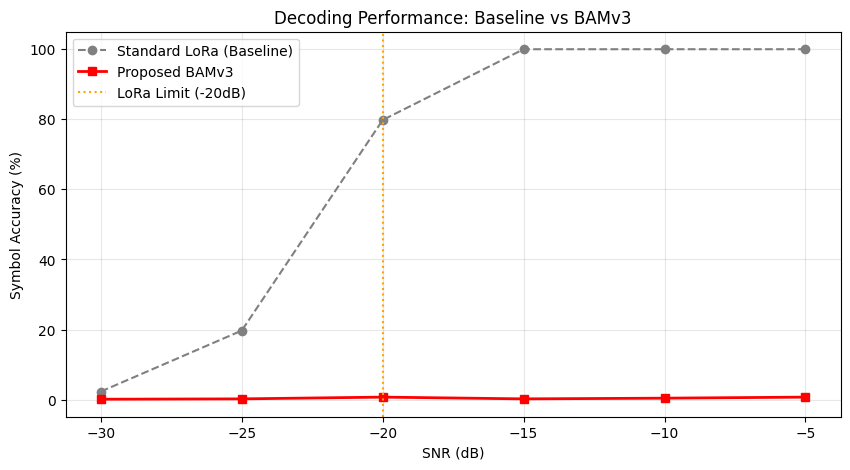

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample

print("\n" + "="*70)
print("📊 QUANTITATIVE PERFORMANCE EVALUATION (Baseline vs BAM)")
print("="*70)

# 1. 테스트 파라미터 설정 ( -30dB 추가 완료 )
NUM_TEST_SAMPLES = 1000  # 샘플 수
TEST_SNR_LEVELS = [-30, -25, -20, -15, -10, -5]  # ⭐ -30dB 추가됨!

# 결과 저장용 딕셔너리
results = {
    snr: {
        'bam_correct': 0, 'bam_total': 0, 'bam_mse': [], 'bam_peak_ratio': [],
        'base_correct': 0, 'base_total': 0, 'base_peak_ratio': [],
    }
    for snr in TEST_SNR_LEVELS
}

print(f"\n🧪 Testing with {NUM_TEST_SAMPLES} samples at each SNR level...")
print(f"SNR levels: {TEST_SNR_LEVELS} dB\n")

for snr in TEST_SNR_LEVELS:
    print(f"\n{'─'*70}")
    print(f"Testing SNR = {snr} dB")
    print(f"{'─'*70}")
    
    for i in range(NUM_TEST_SAMPLES):
        try:
            # 랜덤 심볼 선택
            test_sym = np.random.randint(0, 512)
            
            # 1. 클린 IQ & 노이즈 추가
            clean_iq_test = X_clean_iq[test_sym]
            noisy_iq_test = lora.awgn_iq(clean_iq_test, snr)
            
            # 2. Complex 스펙트로그램 생성
            noisy_flat, noisy_params = generate_complex_spectrogram(noisy_iq_test, fs, bw)
            
            # 3. BAMv3 복원 (Compress -> Decompress)
            compressed = model.compress(noisy_flat.reshape(1, -1))
            restored_flat = model.decompress(compressed).flatten()
            
            # 4. IQ 신호 재구성 (1차)
            iq_restored = reconstruct_iq_from_spectrogram(restored_flat, noisy_params, fs)

            # ====================================================
            # ⭐ [수정] 길이 보정: Trim / Padding + 에너지 정규화
            # ====================================================
            target_len = len(clean_iq_test)
            cur_len = len(iq_restored)

            # (1) 길이 보정: resample 금지, trim / padding만 사용
            if cur_len != target_len:
                if cur_len > target_len:
                    # 가운데 기준으로 잘라서 타이밍 유지
                    diff = cur_len - target_len
                    start = diff // 2
                    end = start + target_len
                    iq_restored = iq_restored[start:end]
                    # print(f"   🔧 Trimmed: {cur_len} -> {target_len}")
                else:
                    # 부족하면 앞/뒤에 0 패딩 (대칭 padding)
                    diff = target_len - cur_len
                    pad_left = diff // 2
                    pad_right = diff - pad_left
                    iq_restored = np.pad(
                        iq_restored,
                        (pad_left, pad_right),
                        mode="constant",
                        constant_values=0,
                    )
                    # print(f"   🔧 Padded: {cur_len} -> {target_len}")
            # else:
            #     print(f"   ✅ Length already matches: {target_len}")

            # (2) 에너지 정규화 (mean/std 표준화 X, power만 맞춤)
            power = np.mean(np.abs(iq_restored) ** 2)
            if power > 1e-12:
                iq_restored = iq_restored / np.sqrt(power)
            # ====================================================

            # 5. Dechirp 및 심볼 추정 (Baseline vs BAM)
            # 기준: 클린 신호
            code_clean, peak_clean = estimate_symbol_custom(clean_iq_test, sf, fs, bw)
            
            # Baseline: noisy 신호
            code_base, peak_base = estimate_symbol_custom(noisy_iq_test, sf, fs, bw)
            
            # BAM 경로: 복원된 IQ
            code_bam, peak_bam = estimate_symbol_custom(iq_restored, sf, fs, bw)
            
            # -----------------------------
            # 결과 기록
            # -----------------------------
            # 1) Baseline Accuracy
            if code_base == test_sym: results[snr]['base_correct'] += 1
            results[snr]['base_total'] += 1
            
            # 2) BAM Accuracy
            if code_bam == test_sym: results[snr]['bam_correct'] += 1
            results[snr]['bam_total'] += 1
            
            # 3) Peak Ratio
            if peak_clean > 0:
                results[snr]['base_peak_ratio'].append(peak_base / peak_clean)
                results[snr]['bam_peak_ratio'].append(peak_bam / peak_clean)
            
            # 4) MSE (복원 품질)
            # MSE 계산 시에는 크기(Scale) 차이 때문에 정규화된 것끼리 비교하거나, 
            # 단순히 복원력 확인용으로만 참고합니다.
            mse = np.mean(np.abs(iq_restored - clean_iq_test)**2)
            results[snr]['bam_mse'].append(mse)
            
        except Exception as e:
            print(f"  ⚠️ Error at sample {i}: {e}")
            results[snr]['base_total'] += 1
            results[snr]['bam_total'] += 1
    
    # 중간 결과 출력
    base_acc = (results[snr]['base_correct'] / results[snr]['base_total'] * 100) if results[snr]['base_total'] > 0 else 0
    bam_acc = (results[snr]['bam_correct'] / results[snr]['bam_total'] * 100) if results[snr]['bam_total'] > 0 else 0
    
    print(f"  ✓ Baseline Acc : {base_acc:.1f}%")
    print(f"  ✓ BAM Accuracy : {bam_acc:.1f}%")

# 최종 결과 요약 출력 및 그래프 그리기 (기존 코드와 동일)
print("\n" + "="*70)
print("📈 FINAL RESULTS SUMMARY")
print("="*70)
print(f"\n{'SNR':<6} {'Base Acc':<10} {'BAM Acc':<10} {'Improvement':<12}")
print("─"*70)

for snr in TEST_SNR_LEVELS:
    b_acc = results[snr]['base_correct'] / results[snr]['base_total'] * 100
    m_acc = results[snr]['bam_correct'] / results[snr]['bam_total'] * 100
    imp = m_acc - b_acc
    print(f"{snr:<6} {b_acc:>8.1f}%  {m_acc:>8.1f}%  {imp:>+10.1f}%p")

# 그래프 그리기
plt.figure(figsize=(10, 5))
snrs = TEST_SNR_LEVELS
base_accs = [results[s]['base_correct']/results[s]['base_total']*100 for s in snrs]
bam_accs = [results[s]['bam_correct']/results[s]['bam_total']*100 for s in snrs]

plt.plot(snrs, base_accs, 'o--', label='Standard LoRa (Baseline)', color='gray')
plt.plot(snrs, bam_accs, 's-', label='Proposed BAMv3', color='red', linewidth=2)
plt.axvline(x=-20, color='orange', linestyle=':', label='LoRa Limit (-20dB)')

plt.xlabel('SNR (dB)')
plt.ylabel('Symbol Accuracy (%)')
plt.title('Decoding Performance: Baseline vs BAMv3')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()